Installing Required Libraries

In [12]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


# Dropout Risk Prediction System

## Objective
This project aims to predict the academic dropout risk level of students 
based on historical academic performance such as SGPA, Backlogs, and Attendance.

The output will be categorized into:
- Low Risk
- Medium Risk
- High Risk

This system enables early counselor intervention.

Import Required Libraries

In [13]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model Saving
import pickle

%matplotlib inline

# 📂 Load Dataset

The dataset contains:
- Semester-wise SGPA
- Semester-wise backlog count
- Attendance percentage

In [14]:
df = pd.read_csv("data/student_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1316, 16)


,HallTicket,SGPA_1-1,Backlog_1-1,SGPA_1-2,Backlog_1-2,SGPA_2-1,Backlog_2-1,SGPA_2-2,Backlog_2-2,SGPA_3-1,Backlog_3-1,SGPA_3-2,Backlog_3-2,SGPA_4-1,Backlog_4-1,Attendance
0,22bq1a0101,4.38,2,6.00,0,1.86,5,5.81,0,6.54,0,6.08,0,6.13,0,84
1,22bq1a0102,2.77,4,2.92,4,0.00,9,0.00,0,0.00,0,0.00,0,0.00,0,91
2,22bq1a0103,4.00,3,5.31,1,2.86,4,5.60,1,6.87,0,5.43,1,5.70,1,92
3,22bq1a0104,6.62,0,6.08,1,7.00,0,6.58,1,7.72,0,7.35,0,7.52,0,85
4,22bq1a0105,3.77,3,4.31,2,4.07,2,5.72,1,7.26,0,6.08,0,5.04,2,89


EXPLORATORY DATA ANALYSIS (EDA)

Attendance Distribution

SGPA Distribution

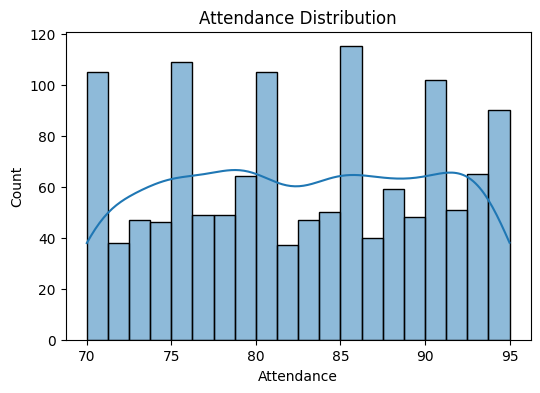

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df["Attendance"], bins=20, kde=True)
plt.title("Attendance Distribution")
plt.show()

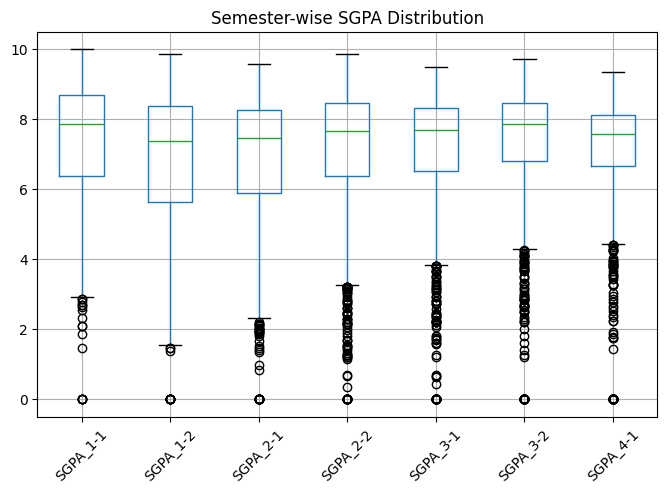

In [16]:
sgpa_cols = sorted([col for col in df.columns if "SGPA" in col])

plt.figure(figsize=(8,5))
df[sgpa_cols].boxplot()
plt.title("Semester-wise SGPA Distribution")
plt.xticks(rotation=45)
plt.show()

# 🔄 Build Next Semester Prediction Dataset

For each student:
- Past academic performance is used as input features.
- Next semester performance is used to define RiskLevel (target).

This simulates real-world early risk prediction.

In [17]:
sgpa_cols = sorted([col for col in df.columns if "SGPA" in col])
backlog_cols = sorted([col for col in df.columns if "Backlog" in col])

data_rows = []

for _, row in df.iterrows():
    
    for i in range(1, len(sgpa_cols)):
        
        # Past Data
        past_sgpas = row[sgpa_cols[:i]]
        past_backlogs = row[backlog_cols[:i]]
        
        past_cgpa = past_sgpas.mean()
        last_sgpa = past_sgpas.iloc[-1]
        
        if len(past_sgpas) > 1:
            sgpa_trend = past_sgpas.iloc[-1] - past_sgpas.iloc[-2]
        else:
            sgpa_trend = 0
        
        total_backlog = past_backlogs.sum()
        
        if len(past_backlogs) > 1:
            backlog_trend = past_backlogs.iloc[-1] - past_backlogs.iloc[-2]
        else:
            backlog_trend = 0
        
        attendance = row["Attendance"]
        
        # Next Semester Data (Target)
        next_sgpa = row[sgpa_cols[i]]
        next_backlog = row[backlog_cols[i]]
        
        # Risk Definition
        if next_sgpa < 4.5 or next_backlog > 5 or attendance < 65:
            risk = "High"
        elif next_sgpa < 6.0 or attendance < 75:
            risk = "Medium"
        else:
            risk = "Low"
        
        data_rows.append([
            past_cgpa,
            last_sgpa,
            sgpa_trend,
            total_backlog,
            backlog_trend,
            attendance,
            risk
        ])

new_df = pd.DataFrame(data_rows, columns=[
    "Past_CGPA",
    "Last_SGPA",
    "SGPA_Trend",
    "Total_Backlog",
    "Backlog_Trend",
    "Attendance",
    "RiskLevel"
])

print("New Dataset Shape:", new_df.shape)
new_df.head()

New Dataset Shape: (7896, 7)


,Past_CGPA,Last_SGPA,SGPA_Trend,Total_Backlog,Backlog_Trend,Attendance,RiskLevel
0,4.3800,4.38,0.00,2,0,84,Low
1,5.1900,6.00,1.62,2,-2,84,High
2,4.0800,1.86,-4.14,7,5,84,Medium
3,4.5125,5.81,3.95,7,-5,84,Low
4,4.9180,6.54,0.73,7,0,84,Low


# 🤖 Model Training

In [18]:
# Encode target
le = LabelEncoder()
new_df["RiskEncoded"] = le.fit_transform(new_df["RiskLevel"])

# Features and target
X = new_df.drop(["RiskLevel", "RiskEncoded"], axis=1)
y = new_df["RiskEncoded"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (6316, 6)
Testing samples: (1580, 6)


# 🌲 Train Random Forest Model

In [19]:
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [20]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

         Feature  Importance
5     Attendance    0.337536
1      Last_SGPA    0.241797
0      Past_CGPA    0.240201
3  Total_Backlog    0.092733
2     SGPA_Trend    0.066275
4  Backlog_Trend    0.021458


# 📊 Model Evaluation

Accuracy: 0.8765822784810127

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.66      0.69       184
           1       0.94      0.96      0.95      1015
           2       0.78      0.76      0.77       381

    accuracy                           0.88      1580
   macro avg       0.81      0.79      0.80      1580
weighted avg       0.87      0.88      0.88      1580



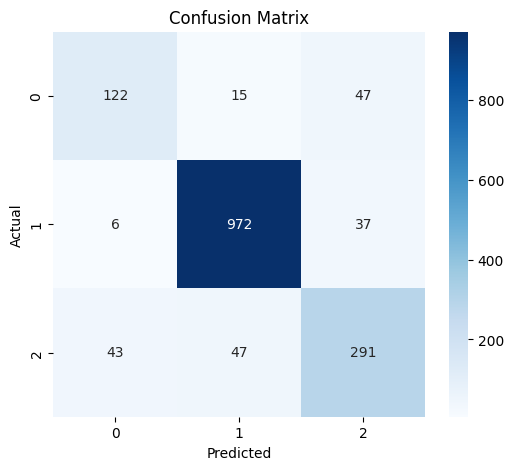

In [21]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
# Save model
pickle.dump(model, open("risk_model.pkl", "wb"))

# Save label encoder
pickle.dump(le, open("label_encoder.pkl", "wb"))

print("Model saved successfully.")

Model saved successfully.
